# IPL Analytics - Exploratory Data Analysis (EDA)

## Objective

The objective of this notebook is to explore the cleaned IPL dataset, identify trends, uncover patterns, and generate insights related to teams, players, venues, and match outcomes.

The findings from this analysis will support feature engineering and machine learning in later stages of the CricketIQ project.

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [22]:
matches = pd.read_csv("C:/Users/anujm/OneDrive/Documents/Desktop/CricketIQ/data/processed/matches_cleaned.csv")
deliveries = pd.read_csv("C:/Users/anujm/OneDrive/Documents/Desktop/CricketIQ/data/processed/deliveries_cleaned.csv")

# IPL Analytics - Exploratory Data Analysis

## Module 1: Match Analytics

### Question 1: How many IPL matches have been played?

In [23]:
print("Total IPL Matches:", matches.shape[0])

Total IPL Matches: 1095


### Observation

The cleaned dataset contains all IPL matches played from the inaugural 2008 season up to the latest available season. It provides a comprehensive historical record of teams, players, venues, and match outcomes.

### Cricket Insight

A large historical dataset increases the reliability of trend analysis and machine learning models by capturing different playing conditions, rule changes, franchise expansions, and evolving T20 strategies over multiple seasons.

### Key Takeaway

The dataset provides sufficient historical coverage to perform meaningful IPL analytics and predictive modeling.

### Question 2: How many matches were played each season? 

In [24]:
matches_per_season = matches.groupby("season")["id"].count()

matches_per_season

season
2007/08    58
2009       57
2009/10    60
2011       73
2012       74
2013       76
2014       60
2015       59
2016       60
2017       59
2018       60
2019       60
2020/21    60
2021       60
2022       74
2023       74
2024       71
Name: id, dtype: int64

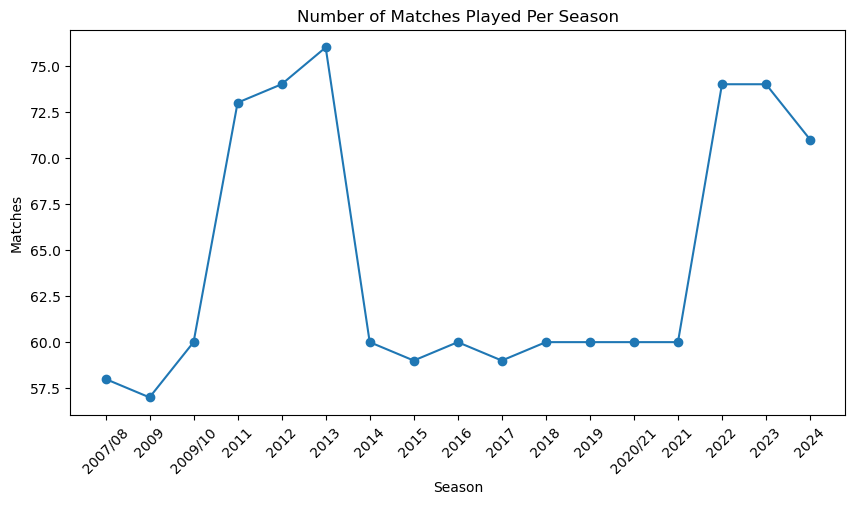

In [25]:
plt.figure(figsize=(10,5))

plt.plot(matches_per_season.index,
         matches_per_season.values,
         marker='o')

plt.title("Number of Matches Played Per Season")
plt.xlabel("Season")
plt.ylabel("Matches")

plt.xticks(rotation=45)

plt.show()

### Observation

The number of IPL matches has generally increased over the years, although a few seasons show temporary declines due to tournament format changes, franchise additions or removals, and external factors such as the COVID-19 pandemic.

### Cricket Insight

The overall upward trend reflects the growth of the IPL as a tournament. As more franchises were introduced and the tournament expanded, the number of matches increased, providing greater opportunities for competition and fan engagement.

### Key Takeaway

The IPL has experienced significant expansion since its inception, making it one of the largest and most competitive T20 leagues in the world.

### Question 3: Which teams have played the most matches 

In [26]:
team1 = matches["team1"].value_counts()

team2 = matches["team2"].value_counts()

matches_played = team1 + team2

matches_played = matches_played.sort_values(ascending=False)

matches_played

Mumbai Indians                 261
Royal Challengers Bengaluru    255
Delhi Capitals                 252
Kolkata Knight Riders          251
Punjab Kings                   246
Chennai Super Kings            238
Rajasthan Royals               221
Sunrisers Hyderabad            182
Deccan Chargers                 75
Pune Warriors                   46
Gujarat Titans                  45
Lucknow Super Giants            44
Gujarat Lions                   30
Rising Pune Supergiants         30
Kochi Tuskers Kerala            14
Name: count, dtype: int64

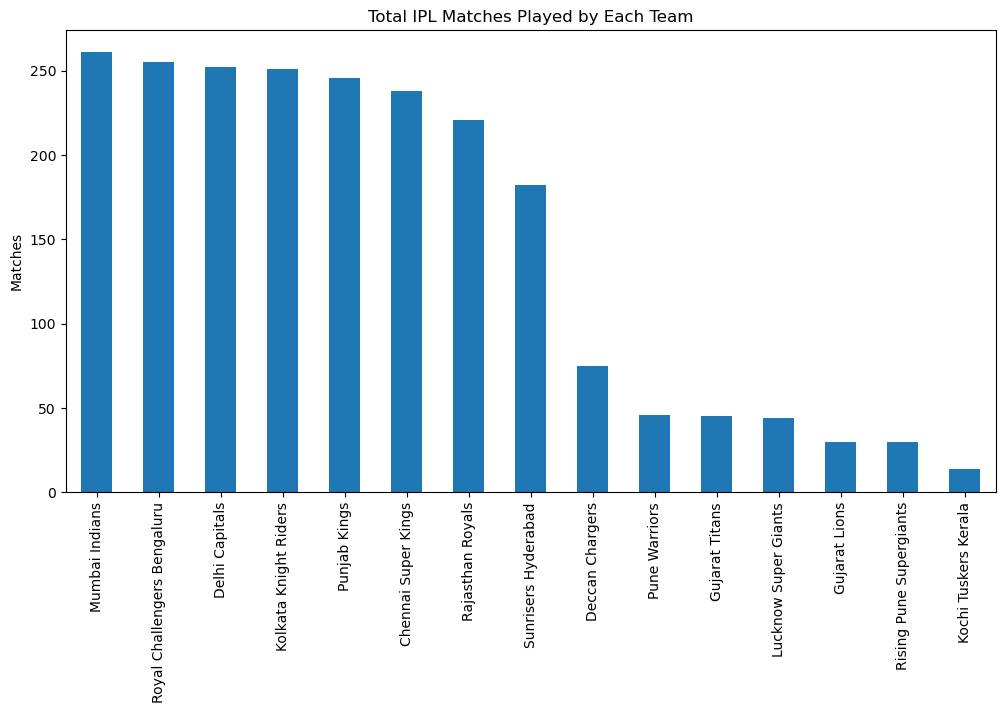

In [27]:
plt.figure(figsize=(12,6))

matches_played.plot(kind="bar")

plt.title("Total IPL Matches Played by Each Team")

plt.ylabel("Matches")

plt.xticks(rotation=90)

plt.show()

### Observation

Mumbai Indians and Royal Challengers Bengaluru have participated in the highest number of IPL matches in the dataset. Teams that joined the tournament in later seasons or participated for only a few seasons have naturally played fewer matche

### Cricket Insight

Franchises that have participated consistently across IPL seasons accumulate greater match experience. However, temporary suspensions, franchise replacements, and the introduction of new teams influence the total number of matches played by each franchis

### Key Takeaway

The total number of matches played by a franchise depends not only on its longevity but also on uninterrupted participation throughout the tournament's history.e.s.y.IPL.

### Question 4: Which teams have won the most matches?

In [9]:
team_wins = matches["winner"].value_counts()

team_wins

winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bengaluru    123
Delhi Capitals                 115
Rajasthan Royals               112
Punjab Kings                   112
Sunrisers Hyderabad             88
Deccan Chargers                 29
Gujarat Titans                  28
Lucknow Super Giants            24
Rising Pune Supergiants         15
Gujarat Lions                   13
Pune Warriors                   12
Kochi Tuskers Kerala             6
Name: count, dtype: int64

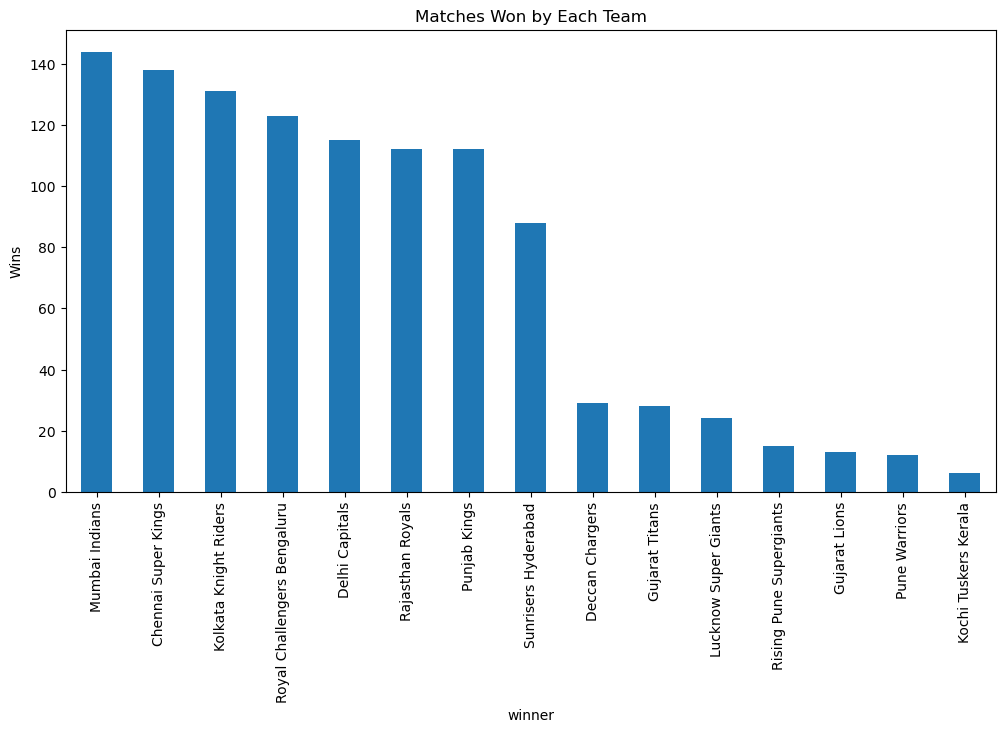

In [10]:
plt.figure(figsize=(12,6))

team_wins.plot(kind="bar")

plt.title("Matches Won by Each Team")

plt.ylabel("Wins")

plt.xticks(rotation=90)

plt.show()

### Observation

Mumbai Indians and Chennai Super Kings, the two most successful franchises of the IPL accounts for the highest number of match victories, while newer teams have fewer wins due to limited participation in the tournament.

### Cricket Insight

Consistently successful teams often benefit from stable leadership, effective player scouting, balanced squad composition, and well-defined long-term strategies, all of which contribute to sustained performance over multiple seasons.

### Key Takeaway

Historical win counts highlight the most successful IPL franchises and provide a useful benchmark for comparing overall team performance.


### Question 5: Does winning the toss really help?

In [11]:
toss_win_match = matches[matches["toss_winner"] == matches["winner"]]

percentage = (len(toss_win_match) / len(matches)) * 100

print(f"Toss Winner also Won Match: {percentage:.2f}%")

Toss Winner also Won Match: 50.59%


### Observation

Approximately 50.59% of matches were won by the team that also won the toss. The percentage is only slightly higher than 50%, indicating a relatively small advantage.

### Cricket Insight

While the toss can influence match strategy, especially under specific pitch or weather conditions, overall team performance, player execution, and match situations have a greater impact on the final result than the toss itself.

### Key Takeaway

Winning the toss provides a slight strategic advantage but does not guarantee victory in IPL matches.

### Question 6: Toss Decision Distribution

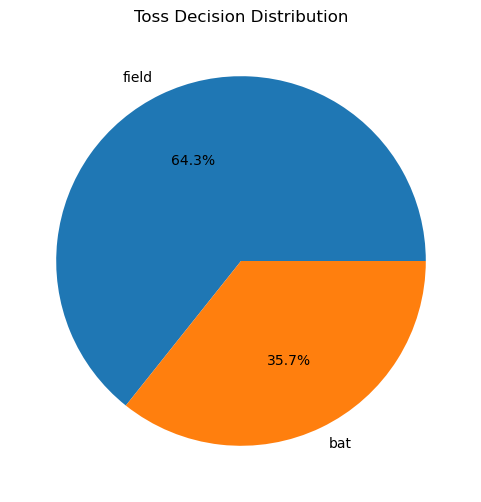

In [12]:
matches["toss_decision"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.title("Toss Decision Distribution")

plt.ylabel("")

plt.show()

### Observation

The majority of captains chose to field first after winning the toss, while comparatively fewer elected to bat first.

### Cricket Insight

Modern T20 cricket generally favors chasing because teams have complete knowledge of the target, can adjust their batting strategy accordingly, and often benefit from dew during evening matches, which makes bowling more challenging in the second innings.

### Key Takeaway

Historical IPL data indicates a clear preference for chasing after winning the toss, reflecting modern T20 tactical trends.

### Question 7: Which Team Has the Highest Win Percentage?

In [13]:
# Total matches played by each team
team1 = matches["team1"].value_counts()
team2 = matches["team2"].value_counts()

matches_played = team1.add(team2, fill_value=0)

# Total wins
wins = matches["winner"].value_counts()

# Win percentage
win_percentage = ((wins / matches_played) * 100).sort_values(ascending=False)

win_percentage

Gujarat Titans                 62.222222
Chennai Super Kings            57.983193
Mumbai Indians                 55.172414
Lucknow Super Giants           54.545455
Kolkata Knight Riders          52.191235
Rajasthan Royals               50.678733
Rising Pune Supergiants        50.000000
Sunrisers Hyderabad            48.351648
Royal Challengers Bengaluru    48.235294
Delhi Capitals                 45.634921
Punjab Kings                   45.528455
Gujarat Lions                  43.333333
Kochi Tuskers Kerala           42.857143
Deccan Chargers                38.666667
Pune Warriors                  26.086957
Name: count, dtype: float64

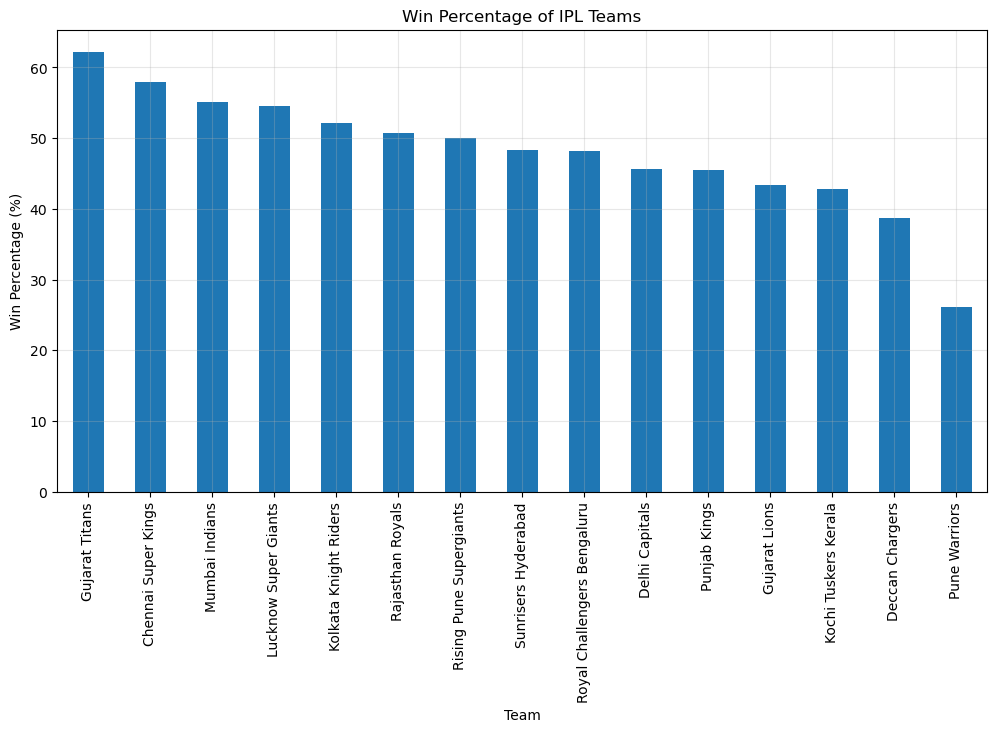

In [14]:
plt.figure(figsize=(12,6))

win_percentage.plot(kind="bar")

plt.title("Win Percentage of IPL Teams")

plt.xlabel("Team")

plt.ylabel("Win Percentage (%)")

plt.xticks(rotation=90)

plt.grid(alpha=0.3)

plt.show()

### Observation

Gujarat Titans have the highest win percentage among all IPL franchises in the dataset. However, unlike long-established teams such as Mumbai Indians, Chennai Super Kings, and Kolkata Knight Riders, Gujarat Titans have participated in only a few IPL seasons, resulting in a comparatively smaller number of matches.

### Cricket Insight

Win percentage is a better metric than total wins when comparing teams with different numbers of matches played. Gujarat Titans exceptional win percentage highlights their remarkable start as a franchise, but it should be interpreted alongside the relatively smaller sample size. Sustaining such performance over many more seasons will be a stronger indicator of long-term consistency.

### Key Takeaway

Gujarat Titans have been the most efficient team in terms of converting matches into victories since their debut, while franchises like Mumbai Indians and Chennai Super Kings have demonstrated sustained excellence over a much larger number of matches and seasons.

> **Note:** Win percentage should always be interpreted along with the number of matches played. Teams with fewer matches may show unusually high or low percentages because of the smaller sample size.

### Question 8: Which Teams Perform Better While Chasing?

In [15]:
# Teams that won while chasing

chasing_wins = matches[matches["result"] == "wickets"]["winner"].value_counts()

chasing_wins

winner
Kolkata Knight Riders          76
Mumbai Indians                 71
Rajasthan Royals               67
Chennai Super Kings            67
Delhi Capitals                 66
Royal Challengers Bengaluru    64
Punjab Kings                   58
Sunrisers Hyderabad            43
Gujarat Titans                 17
Gujarat Lions                  12
Deccan Chargers                11
Rising Pune Supergiants         8
Lucknow Super Giants            8
Pune Warriors                   6
Kochi Tuskers Kerala            4
Name: count, dtype: int64

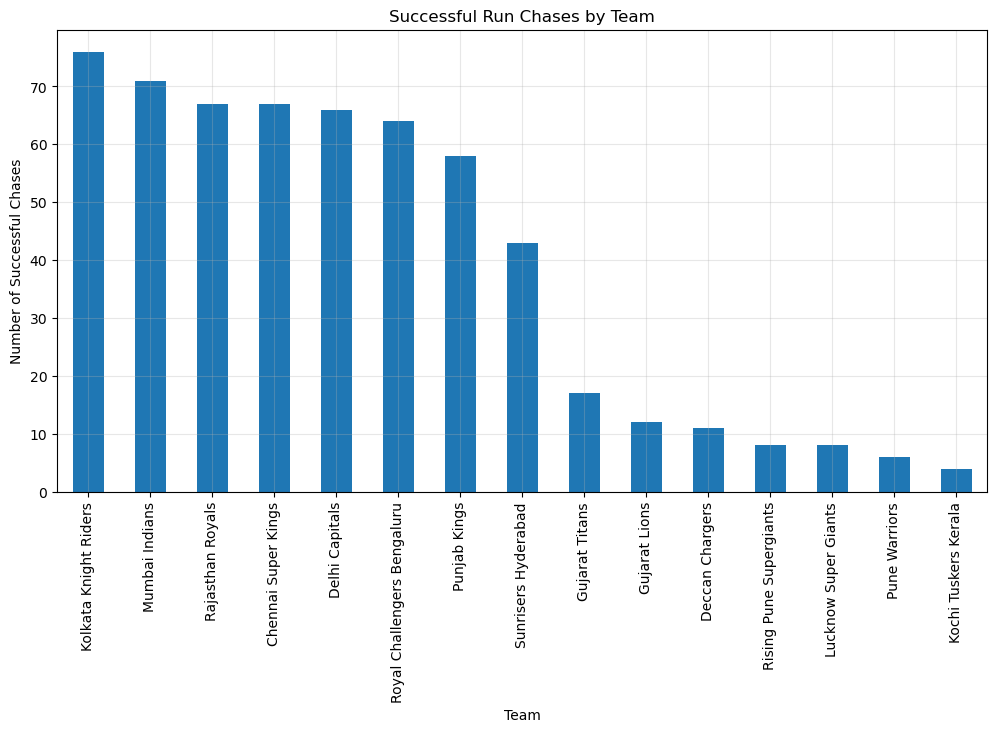

In [16]:
plt.figure(figsize=(12,6))

chasing_wins.plot(kind="bar")

plt.title("Successful Run Chases by Team")

plt.xlabel("Team")

plt.ylabel("Number of Successful Chases")

plt.xticks(rotation=90)

plt.grid(alpha=0.3)

plt.show()

### Observation

Kolkata Knight Riders have recorded the highest number of successful run chases in the IPL, followed closely by Mumbai Indians and Rajasthan Royals.Newer franchises such as Gujarat Titans and Lucknow Super Giants have comparatively fewer successful chases due to their shorter participation in the tournament.

### Cricket Insight

Successful run chases are often an indicator of a team's batting depth, finishing ability, and composure under pressure. Franchises that have consistently performed well while chasing typically possess experienced middle-order batters and finishers who can adapt their strategy based on the required run rate. However, the total number of successful chases should always be interpreted alongside the number of seasons and matches played by each franchise.

### Key Takeaway

Historically, Kolkata Knight Riders and Mumbai Indians have been among the most successful chasing teams in the IPL. While newer franchises currently have fewer successful chases, a chase success rate analysis would provide a fairer comparison by accounting for differences in the number of matches played.

### Question 9: Which Teams Defend Totals Best?

In [17]:
defending_wins = matches[matches["result"] == "runs"]["winner"].value_counts()

defending_wins

winner
Chennai Super Kings            71
Mumbai Indians                 71
Royal Challengers Bengaluru    57
Kolkata Knight Riders          54
Punjab Kings                   51
Delhi Capitals                 46
Sunrisers Hyderabad            44
Rajasthan Royals               43
Deccan Chargers                18
Lucknow Super Giants           16
Gujarat Titans                 11
Rising Pune Supergiants         7
Pune Warriors                   6
Kochi Tuskers Kerala            2
Gujarat Lions                   1
Name: count, dtype: int64

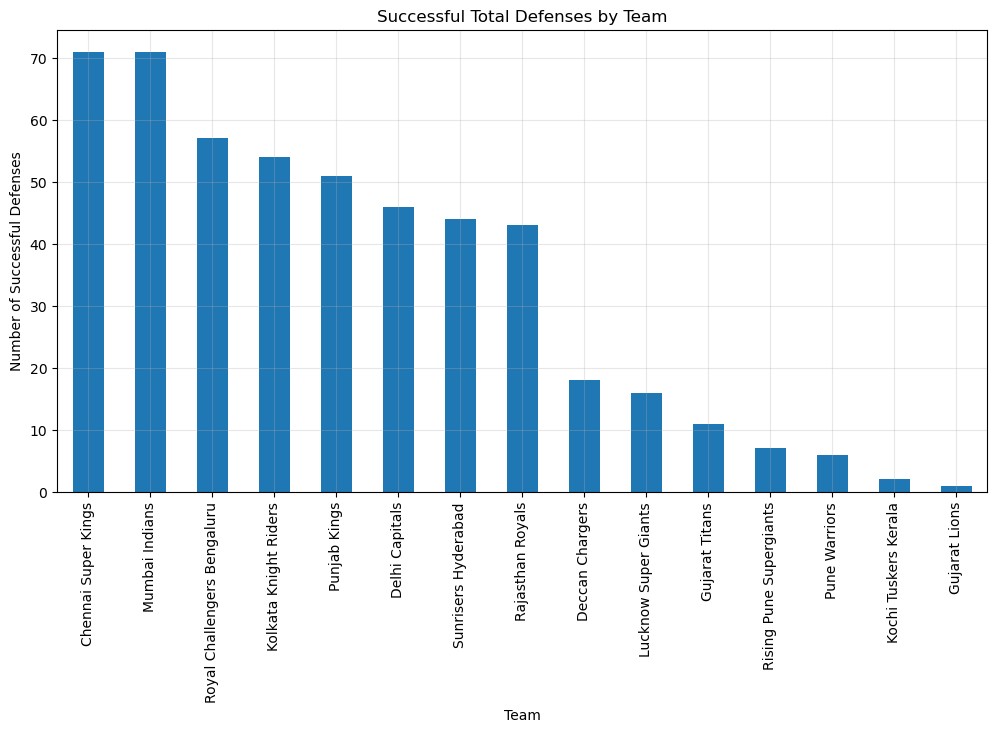

In [18]:
plt.figure(figsize=(12,6))

defending_wins.plot(kind="bar")

plt.title("Successful Total Defenses by Team")

plt.xlabel("Team")

plt.ylabel("Number of Successful Defenses")

plt.xticks(rotation=90)

plt.grid(alpha=0.3)

plt.show()

### Observation

Chennai Super Kings and Mumbai Indians have recorded the highest number of successful total defenses in IPL history. Royal Challengers Bengalu and , Kolkata Knight Ridegs also feature among the top teams in defending first-innings totals. Newer franchises such as Gujarat Titans and Lucknow Super Giants have fewer successful defenses due to their shorter participation in the tournamten

### Cricket Insight
Successfully defending a target requires disciplined bowling, smart field placements, and effective captaincy under pressure. The consistent presence of Chennai Super Kings and Mumbai Indians at the top reflects their ability to build strong bowling attacks and execute defensive strategies effectively. However, the total number of successful defenses should be interpreted alongside the number of matches played by each franchise.
.

### Key Takeaway

Historically, Chennai Super Kings and Mumbai Indians have been the strongest teams at defending totals, highlighting the importance of experienced bowlers and tactical leadership in winning matches while batting first.e.t.

### Question 10: Which Teams Win More Often After Winning the Toss?

In [19]:
toss_match_wins = matches[matches["toss_winner"] == matches["winner"]]

team_toss_success = toss_match_wins["winner"].value_counts()

team_toss_success

winner
Mumbai Indians                 78
Chennai Super Kings            75
Kolkata Knight Riders          68
Delhi Capitals                 61
Royal Challengers Bengaluru    61
Rajasthan Royals               60
Punjab Kings                   45
Sunrisers Hyderabad            38
Deccan Chargers                19
Gujarat Titans                 14
Gujarat Lions                  10
Lucknow Super Giants           10
Rising Pune Supergiants         8
Kochi Tuskers Kerala            4
Pune Warriors                   3
Name: count, dtype: int64

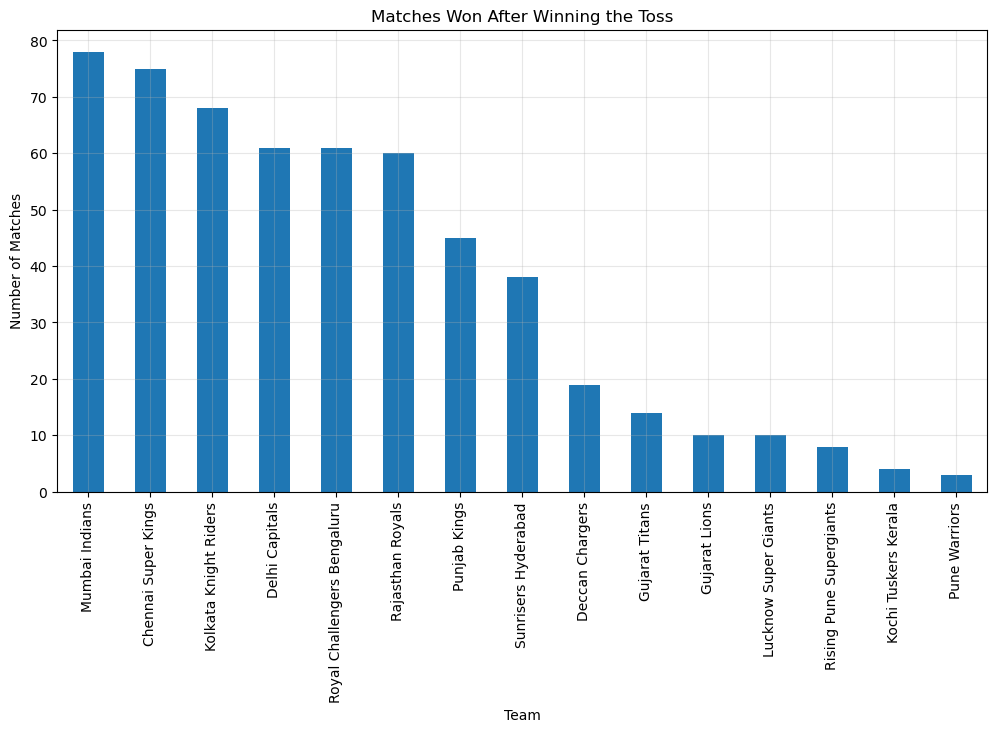

In [20]:
plt.figure(figsize=(12,6))

team_toss_success.plot(kind="bar")

plt.title("Matches Won After Winning the Toss")

plt.xlabel("Team")

plt.ylabel("Number of Matches")

plt.xticks(rotation=90)

plt.grid(alpha=0.3)

plt.show()

### Observation

Mumbai Indians have won the highest number of matches after winning the toss, followed closely by Chennai Super Kings. Kolkata Knight Riders and Royal Challengers Bengaluru have also converted a significant number of toss victories into match wins. Newer franchises have fewer such victories because they have participated in fewer IPL seasons.

### Cricket Insight

Winning the toss provides teams with an opportunity to make strategic decisions based on pitch conditions, weather, and match situations. However, winning the toss alone does not guarantee victory. Teams like Mumbai Indians and Chennai Super Kings have consistently capitalized on toss advantages through better tactical execution, balanced squads, and strong on-field decision-makin

### Key Takeaway
While the toss can provide a tactical advantage, a team's ability to convert that advantage into victories depends on overall team performance rather than the toss itself. Successful franchises consistently combine smart toss decisions with strong batting, bowling, and fieng ldiperfonrmac.g.